<a href="https://colab.research.google.com/github/GuilleeSS/MyRepo/blob/main/lab5NM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1D Newton Optimization Results:
Initial: 0.5   -> Found Optimum: 0.507189 in 3 iterations (f(x) = 0.4549)
Initial: 1.2   -> Found Optimum: 1.228295 in 4 iterations (f(x) = -1.2036)
Initial: 1.8   -> Found Optimum: 1.994666 in 5 iterations (f(x) = 1.9792)


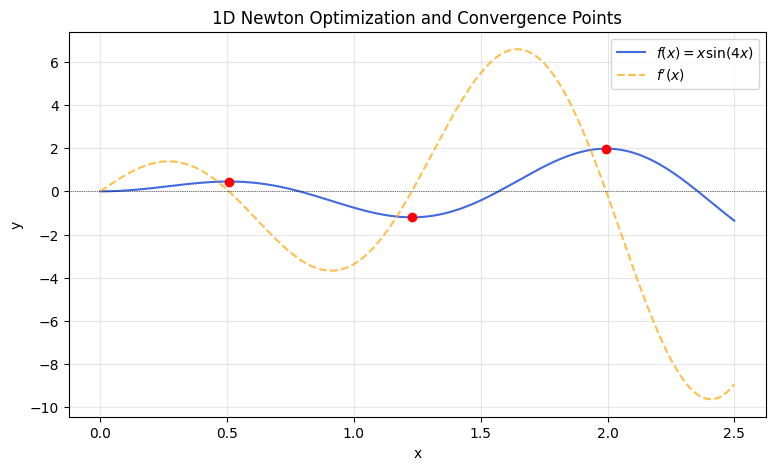

In [9]:
import numpy as np
import matplotlib.pyplot as plt

#Implementation 1D Maximization

# Objective function
def f(x):
    return x * np.sin(4 * x)

# First derivative (gradient)
def g(x):
    return np.sin(4 * x) + 4 * x * np.cos(4 * x)

# Second derivative (Hessian)
def h(x):
    return 8 * np.cos(4 * x) - 16 * x * np.sin(4 * x)

def newton_method_1d(f, g, h, x0, tol=1e-8, max_iter=100):
    x = x0
    history = [x]

    for i in range(max_iter):
        g_val = g(x)
        h_val = h(x)

        if abs(h_val) < 1e-12:
            print("Warning: Derivative close to zero. Step skipped.")
            break

        x_next = x - g_val / h_val
        history.append(x_next)

        if abs(x_next - x) < tol:
            break
        x = x_next

    return x, history

# Testing with different initial guesses
roots = []
initial_guesses = [0.5, 1.2, 1.8]

print("1D Newton Optimization Results:")
for x0 in initial_guesses:
    root, hist = newton_method_1d(f, g, h, x0)
    roots.append(root)
    print(f"Initial: {x0:<5} -> Found Optimum: {root:.6f} in {len(hist)-1} iterations (f(x) = {f(root):.4f})")

# Visualization
x_vals = np.linspace(0, 2.5, 500)
plt.figure(figsize=(9, 5))
plt.plot(x_vals, f(x_vals), label='$f(x) = x \\sin(4x)$', color='royalblue')
plt.plot(x_vals, g(x_vals), '--', label="$f'(x)$", color='orange', alpha=0.7)

for r in roots:
    plt.plot(r, f(r), 'ro')
plt.axhline(0, color='black', linewidth=0.5, ls=':')
plt.title("1D Newton Optimization and Convergence Points")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

1D Newton Optimization Results:
Initial: 0.5   -> Found Optimum: 0.507189 in 3 iterations (f(x) = 0.4549)
Initial: 1.2   -> Found Optimum: 1.228295 in 4 iterations (f(x) = -1.2036)
Initial: 1.8   -> Found Optimum: 1.994666 in 5 iterations (f(x) = 1.9792)


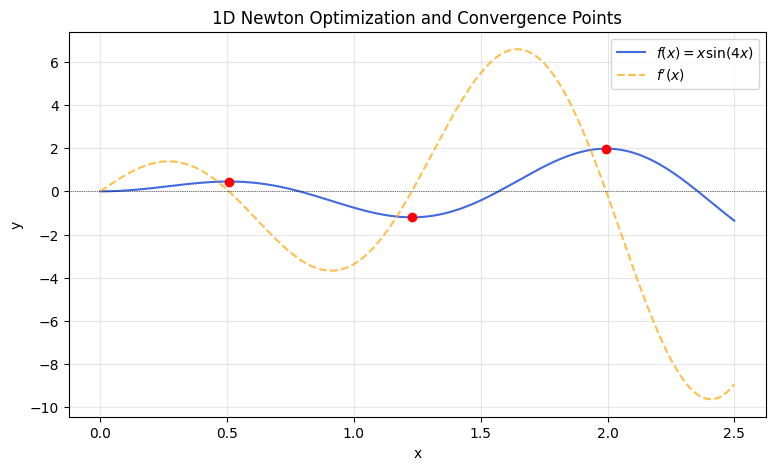

In [10]:
import numpy as np
import matplotlib.pyplot as plt

#Implementation Multivariate Newton's Method

# Objective function
def f(x):
    return x * np.sin(4 * x)

# First derivative (gradient)
def g(x):
    return np.sin(4 * x) + 4 * x * np.cos(4 * x)

# Second derivative (Hessian)
def h(x):
    return 8 * np.cos(4 * x) - 16 * x * np.sin(4 * x)

def multivariate_newton(grad_func, hess_func, x0, tol=1e-6, max_iter=100):
    """
    Finds the roots of a vector-valued gradient function (or optimizes an objective function).
    """
    x = np.array(x0, dtype=float)
    history = [x.copy()]

    for _ in range(max_iter):
        grad = grad_func(x)
        hess = hess_func(x)

        # Solving H * delta_x = -grad using standard LU decomposition approach
        try:
            delta_x = np.linalg.solve(hess, -grad)
        except np.linalg.LinAlgError:
            print("Hessian is singular. Stopping optimization.")
            break

        x_next = x + delta_x
        history.append(x_next.copy())

        if np.linalg.norm(delta_x) < tol:
            break

        x = x_next

    return x, np.array(history)

# Testing with different initial guesses
roots = []
initial_guesses = [0.5, 1.2, 1.8]

print("1D Newton Optimization Results:")
for x0 in initial_guesses:
    root, hist = newton_method_1d(f, g, h, x0)
    roots.append(root)
    print(f"Initial: {x0:<5} -> Found Optimum: {root:.6f} in {len(hist)-1} iterations (f(x) = {f(root):.4f})")

# Visualization
x_vals = np.linspace(0, 2.5, 500)
plt.figure(figsize=(9, 5))
plt.plot(x_vals, f(x_vals), label='$f(x) = x \\sin(4x)$', color='royalblue')
plt.plot(x_vals, g(x_vals), '--', label="$f'(x)$", color='orange', alpha=0.7)

for r in roots:
    plt.plot(r, f(r), 'ro')
plt.axhline(0, color='black', linewidth=0.5, ls=':')
plt.title("1D Newton Optimization and Convergence Points")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
from scipy.special import digamma, polygamma

#Application: Maximum Likelihood Estimation (MLE)

# Synthetic data generation for testing (True params: alpha=2.5, beta=1.5)
np.random.seed(42)
true_alpha, true_beta = 2.5, 1.5
data = np.random.gamma(shape=true_alpha, scale=true_beta, size=500)

# Compute necessary sample sums
sum_ln_x = np.sum(np.log(data))
sum_x = np.sum(data)
N = len(data)

def mle_gradient(params):
    alpha, beta = params[0], params[1]

    # Partial derivatives
    d_alpha = sum_ln_x - N * np.log(beta) - N * digamma(alpha)
    d_beta = (sum_x / (beta ** 2)) - (N * alpha / beta)

    return np.array([d_alpha, d_beta])

def mle_hessian(params):
    alpha, beta = params[0], params[1]

    # Trigamma is the 1st derivative of digamma (polygamma order 1)
    trigamma = polygamma(1, alpha)

    d_alpha_alpha = -N * trigamma
    d_beta_beta = - (2 * sum_x / (beta ** 3)) + (N * alpha / (beta ** 2))
    d_alpha_beta = -N / beta

    return np.array([
        [d_alpha_alpha, d_alpha_beta],
        [d_alpha_beta,  d_beta_beta]
    ])

# Optimization execution
initial_guess = [1.0, 1.0]
estimated_params, path = multivariate_newton(mle_gradient, mle_hessian, initial_guess)

print("\nMLE Estimation via Multivariate Newton's Method:")
print(f"True Parameters:      alpha = {true_alpha:.2f}, beta = {true_beta:.2f}")
print(f"Estimated Parameters: alpha = {estimated_params[0]:.4f}, beta = {estimated_params[1]:.4f}")
print(f"Converged in {len(path)-1} iterations.")


MLE Estimation via Multivariate Newton's Method:
True Parameters:      alpha = 2.50, beta = 1.50
Estimated Parameters: alpha = 2.7116, beta = 1.3733
Converged in 6 iterations.
